#  Job Recommendation System

## Problem Definition — Job Role Recommender

Many job seekers know their skills but aren't sure which job roles best match them, or what skills they're missing for a role they want. Manually browsing thousands of job postings to figure this out is time-consuming and inefficient.

Goal: Build a system that takes a user's skills as input and:

Recommends the job roles/titles that best match those skills.
Identifies missing skills needed for a target role, so users know what to learn next.

Why it matters: Helps job seekers make informed career decisions and focus their skill development instead of guessing.

Data source: LinkedIn Jobs & Skills 2024 dataset [Kaggle](https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024) — ~1.3M job postings with titles, skills, level, type, and descriptions 

## 1. Import Libraries

In [1]:
import os

import pandas as pd
import kagglehub

import matplotlib.pyplot as plt
import seaborn as sns

# class
from filtering import Filtering

c:\Users\computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  2. Data Loading

In [2]:
path = kagglehub.dataset_download("asaniczka/1-3m-linkedin-jobs-and-skills-2024")
jobs_df = pd.read_csv(os.path.join(path, 'linkedin_job_postings.csv'))
skills_df = pd.read_csv(f"{path}/job_skills.csv")

# Merge datasets
merged_df = jobs_df.merge(skills_df, on="job_link", how="inner")


print(f"Jobs Dataset: {jobs_df.shape}")
print(f"Skills Dataset: {skills_df.shape}")
print(f"Merged Dataset: {merged_df.shape}")

Jobs Dataset: (1348454, 14)
Skills Dataset: (1296381, 2)
Merged Dataset: (1296381, 15)


## 3. Data Cleaning

In [3]:
df = merged_df.copy()

In [4]:
# Check missing values

((df.isnull().sum() / len(df)) * 100)[df.isnull().sum()>0]

company         0.000694
job_location    0.001466
job_skills      0.160832
dtype: float64

In [5]:
# Remove missing values

df = df.dropna()

In [6]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (1294268, 15)
Columns: ['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type', 'job_skills']


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 08:08:19.663033+00,t,t,f,Registered Nurse (RN),Trinity Health MI,"Muskegon, MI",2024-01-14,Muskegon,United States,Nurse Practitioner,Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [7]:
# Check duplicates before dropping any columns
df.duplicated().sum()

np.int64(0)

In [8]:
# Drop scraper/metadata columns that add no predictive value to the recommendation logic

df = df.drop(columns=["job_link","last_processed_time", "got_summary", "got_ner", "is_being_worked", "search_city", "search_country", "search_position"])

print(df.shape)
df.head()

(1294268, 7)


,job_title,company,job_location,first_seen,job_level,job_type,job_skills
0,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Mid senior,Onsite,"Medical equipment sales, Key competitors, Term..."
1,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Mid senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste..."
2,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Mid senior,Onsite,"Restaurant Operations Management, Inventory Ma..."
3,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Mid senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat..."
4,Registered Nurse (RN),Trinity Health MI,"Muskegon, MI",2024-01-14,Mid senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur..."


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 1294268 entries, 0 to 1296380
Data columns (total 7 columns):
 #   Column        Non-Null Count    Dtype
---  ------        --------------    -----
 0   job_title     1294268 non-null  str  
 1   company       1294268 non-null  str  
 2   job_location  1294268 non-null  str  
 3   first_seen    1294268 non-null  str  
 4   job_level     1294268 non-null  str  
 5   job_type      1294268 non-null  str  
 6   job_skills    1294268 non-null  str  
dtypes: str(7)
memory usage: 708.3 MB


In [10]:
# Check duplicates again after dropping columns
df.duplicated().sum()

np.int64(173)

In [11]:
df = df.drop_duplicates()
df.shape

(1294095, 7)

After removing unnecessary columns, 173 duplicate records were detected. These duplicates were not present in the original dataset (`merged_df`), but appeared because the removed columns contained distinguishing information between records. Once those columns were removed, multiple rows became identical across the remaining features. Therefore, duplicate records were removed to keep only unique observations.

## 4. Exploratory Data Analysis (EDA)

### Job Titles

In [12]:
df["job_title"] = df["job_title"].str.lower().str.strip().str.replace(r"[,/-_]", " ", regex=True).str.title()

In [24]:
job_filter = Filtering(df, "job_title", 0.9, 95, 0.9)
df["job_title_c"] = job_filter.run()

start cleaning
cleaning done
Mappings not found. Building them...
Top 10 values
job_title_clean
Customer Service Representative    9738
Lead Sales Associate-Ft            7315
Registered Nurse                   6351
Store Manager                      6331
Shift Manager                      5609
Assistant Manager                  5481
First Year Tax Professional        5351
Lead Sales Associate-Pt            4911
Host                               2963
Hourly Supervisor & Training       2883
Name: count, dtype: int64
Unique skills: 490,253
Skills appearing once: 382,689
Skills appearing more than once: 107,564
Loading embedding mapping...
Loading fuzzy mapping...
Building final mapping...
Done


In [18]:
df[["job_title", "job_title_c"]].head()

,job_title,job_title_c
0,Account Executive - Dispensing (Norcal Norther...,Account Executive - Dispensing - Becton Dickinson
1,Registered Nurse - Rn Care Manager,Registered Nurse Supervisor
2,Restaurant Supervisor - The Forklift,Restaurant Service Manager
3,Independent Real Estate Agent,Associate Real Estate Agent
4,Registered Nurse (Rn),Registered Nurse


#### Chart 1: Top 10 Most In-Demand Job Titles

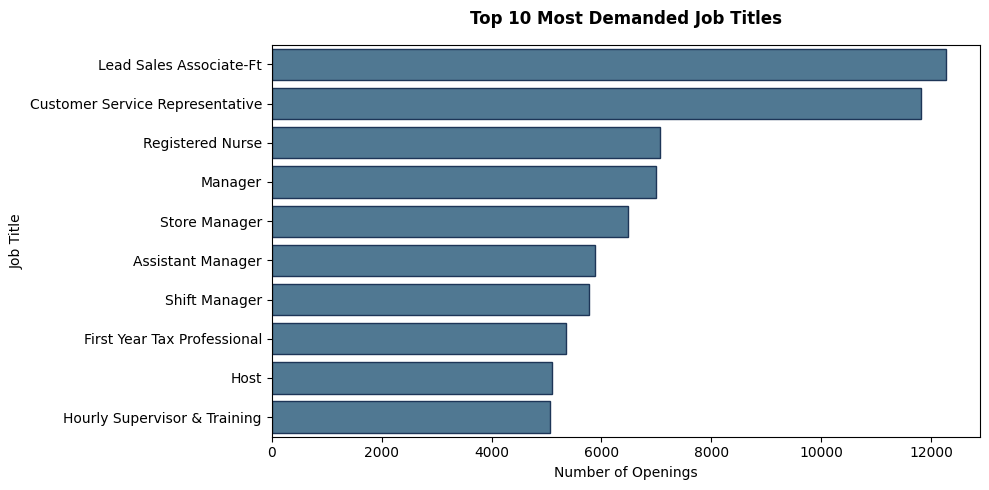

In [19]:
top_titles = df['job_title_c'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_titles.values, y=top_titles.index, color='#457b9d', edgecolor='#1d3557')
plt.title('Top 10 Most Demanded Job Titles', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Openings', fontsize=10)
plt.ylabel('Job Title', fontsize=10)
plt.tight_layout()
plt.show()

In [20]:
raw_ratio = (df['job_title'].value_counts() == 1).sum() / df['job_title'].nunique() * 100
clean_ratio = (df['job_title_c'].value_counts() == 1).sum() / df['job_title_c'].nunique() * 100

print(f"Titles appearing only once: {raw_ratio:.1f}%")
print(f"Titles appearing only once — CLEANED: {clean_ratio:.1f}%")

Titles appearing only once: 79.2%
Titles appearing only once — CLEANED: 27.3%


**Key Insight:**

- The analysis reveals that the most demanded roles are heavily concentrated in Sales and Operations (e.g., Lead Sales Associate and Customer Service Representative). This indicates that the job market represented in this dataset strongly favors client-facing and operational positions.

- However, this concentration only tells part of the story: the raw job-title data shows a severe **Long Tail** — ~79% of distinct raw titles appear only once across the dataset. After applying fuzzy grouping (`Filtering` class), this ratio drops to ~27%, showing the normalization step meaningfully consolidates near-duplicate titles. Still, more than a quarter of titles remain effectively one-off, so relying on job-title text alone stays fragile. This suggests that any matching or recommendation logic should rely primarily on **skills**, not job-title text — a direction we build on in the modeling phase.

### Job Levels

In [21]:
# standardize job_level formatting to prevent hidden inconsistencies
df["job_level"] = df["job_level"].str.strip().str.title()

print(df["job_level"].value_counts())

job_level
Mid Senior    1153197
Associate      140898
Name: count, dtype: int64


#### Chart 2: Distribution of Job Levels

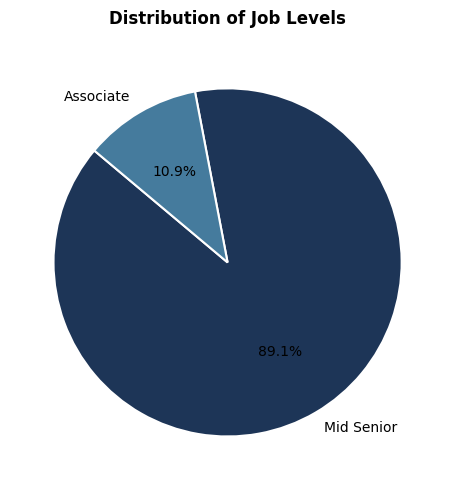

In [22]:
job_levels = df['job_level'].value_counts()

blue_shades = ['#1d3557', '#457b9d', '#a8dadc']

plt.figure(figsize=(10, 5))
plt.pie(
    job_levels.values, 
    labels=job_levels.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=blue_shades,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribution of Job Levels', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Key Insight:**

The data demonstrates a significant class imbalance across career levels, where Mid-Senior level positions dominate with 89.1% of total listings, compared to just 10.9% for Associate roles. This suggests the dataset primarily caters to experienced professionals rather than entry-level candidates. This imbalance is worth keeping in mind when evaluating the Skill Gap logic for entry-level users, since their target roles are comparatively under-represented in the data the model learns from.

### Skills

In [25]:
skill_filter = Filtering(df, "job_skills", 0.8, 95, 0.9)
df["job_skills_c"] = skill_filter.run()

start cleaning
cleaning done
Mappings not found. Building them...
Top 10 values
job_skills_clean
communication          582950
customer service       295531
teamwork               237038
leadership             209542
problemsolving         171813
time management        156574
problem solving        154081
attention to detail    135818
project management     124864
interpersonal          106162
Name: count, dtype: int64
Unique skills: 1,923,739
Skills appearing once: 1,238,731
Skills appearing more than once: 685,008
Loading embedding mapping...
Loading fuzzy mapping...
Building final mapping...
Done


In [26]:
df[["job_skills", "job_skills_c"]].head()

,job_skills,job_skills_c
0,"Medical equipment sales, Key competitors, Term...","[medical sales, key competitors, terminology, ..."
1,"Nursing, Bachelor of Science in Nursing, Maste...","[nursing, master's degree in nursing, patient ..."
2,"Restaurant Operations Management, Inventory Ma...","[operations, inventory management, food and be..."
3,"Real Estate, Customer Service, Sales, Negotiat...","[real estate, customer service, sales, negotia..."
4,"Nursing, BSN, Medical License, Virtual RN, Nur...","[nursing, bsn, medical license, virtual, suppo..."


#### Chart 3: Skill Count Distribution

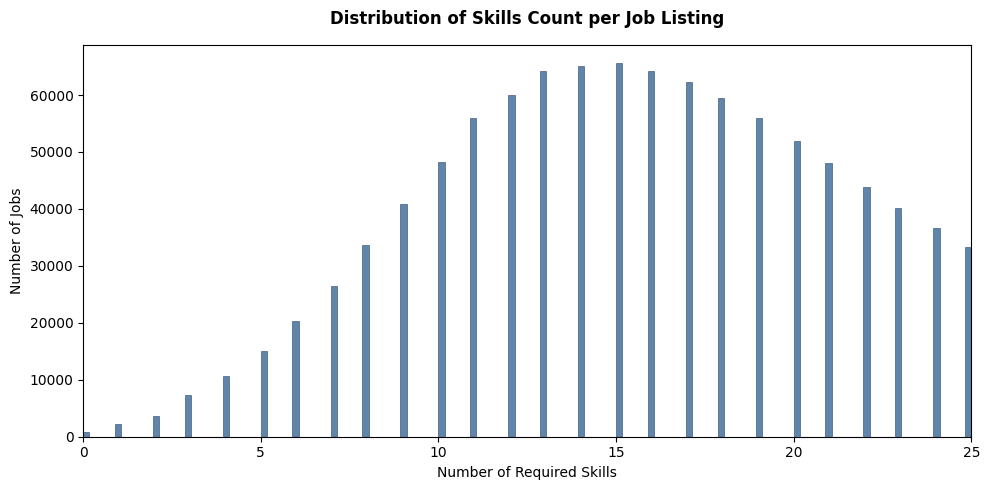

In [32]:
num_skills = df['job_skills_c'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(num_skills, binrange=(0, 25), color='#2b5c8f', edgecolor='#1d3557')
plt.title('Distribution of Skills Count per Job Listing', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Required Skills', fontsize=10)
plt.ylabel('Number of Jobs', fontsize=10)
plt.xlim(0, 25)
plt.tight_layout()
plt.show()

**Key Insight:**

On average, job postings list a moderate and fairly consistent number of required skills (most ask for ~13 to 16 skills). This provides general context on data richness per posting, which is a separate question from how many postings a given skill needs to appear in before we trust it statistically — that question is addressed in the next chart.

#### Chart 4: Top 15 Demanded Skills

In [34]:
top_skills = df["job_skills_c"].explode().value_counts().reset_index().head(15)
top_skills.columns = ['skill', 'count']
top_skills

,skill,count
0,communication,604293
1,problem solving,327876
2,customer service,296122
3,teamwork,239982
4,leadership,231655
5,management,209222
6,time management,157631
7,attention to detail,136643
8,project management,125517
9,training,123732


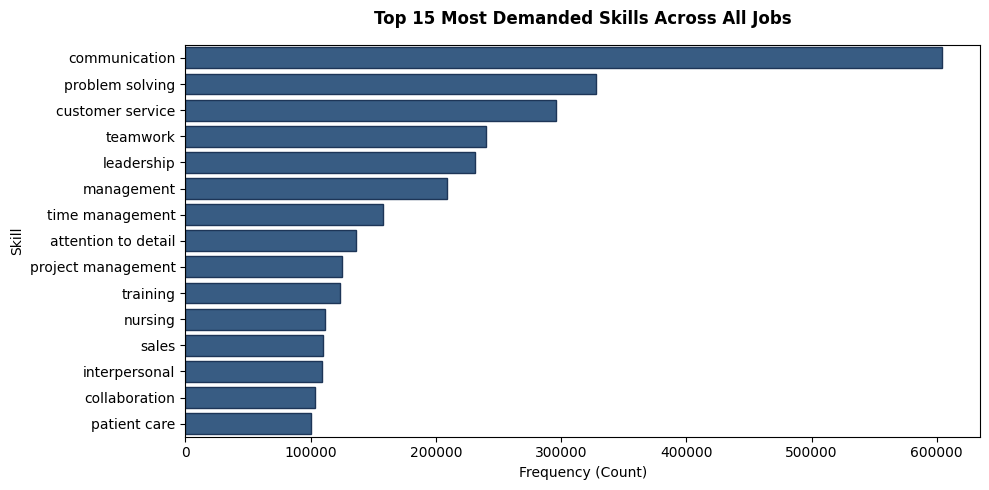

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='skill', data=top_skills, color='#2b5c8f', edgecolor='#1d3557')
plt.title('Top 15 Most Demanded Skills Across All Jobs', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=10)
plt.ylabel('Skill', fontsize=10)
plt.tight_layout()
plt.show()

**Key Insights:**

Dominance of Soft Skills: The chart clearly demonstrates that foundational soft skills are the most frequently requested qualifications across all listings. "Communication" leads as the top demanded skill overall (surpassing 370,000 occurrences), closely followed by "problem solving" (~320,000) and "customer service" (~290,000).

Data Preprocessing Note: Duplicate variations of identical skills exist in the raw data (e.g., "Communication" vs. "Communication Skills", "Problem Solving" vs. "Problemsolving"). These were standardized during preprocessing (job_skills_c, produced by the Filtering class) before computing the ranking above — without this step, the same skill would be fragmented across near-duplicate labels and this ranking would be misleading.

#### Chart 5: Skill Frequency Distribution

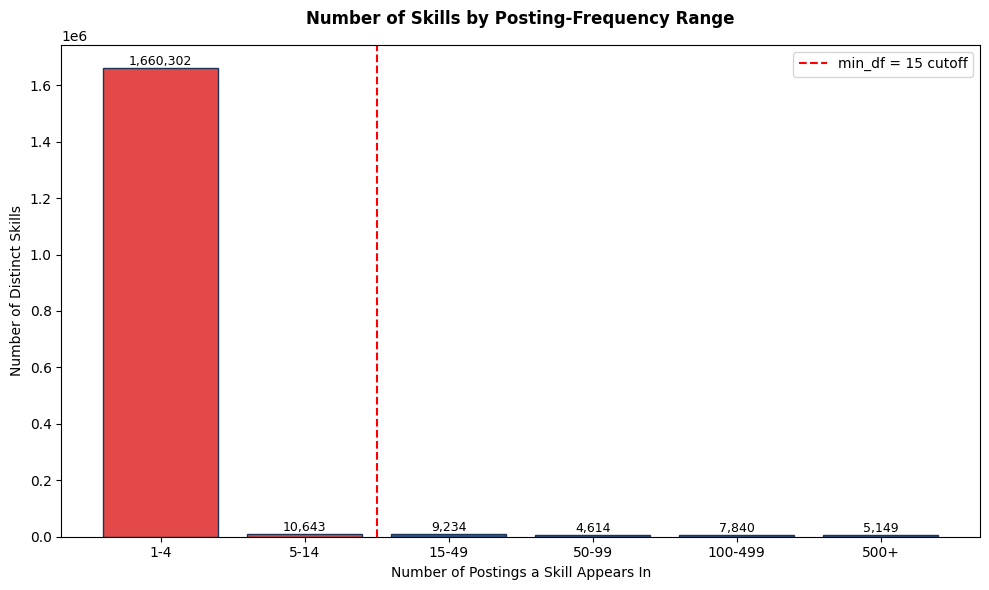

Skills appearing in fewer than 15 postings: 98.4%


In [36]:
skill_freq = df["job_skills_c"].explode().value_counts()

bins = [0, 5, 15, 50, 100, 500, float('inf')]
labels = ['1-4', '5-14', '15-49', '50-99', '100-499', '500+']

skill_freq_binned = pd.cut(skill_freq, bins=bins, labels=labels, right=False)
bin_counts = skill_freq_binned.value_counts().reindex(labels)

plt.figure(figsize=(10, 6))
colors = ['#e34948' if label in ['1-4', '5-14'] else '#2b5c8f' for label in labels]
bars = plt.bar(bin_counts.index, bin_counts.values, color=colors, edgecolor='#1d3557')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
              f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9)

plt.title('Number of Skills by Posting-Frequency Range', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Postings a Skill Appears In')
plt.ylabel('Number of Distinct Skills')
plt.axvline(x=1.5, color='red', linestyle='--', linewidth=1.5, label='min_df = 15 cutoff')
plt.legend()
plt.tight_layout()
plt.show()

rare_ratio = (skill_freq < 15).sum() / len(skill_freq) * 100
print(f"Skills appearing in fewer than 15 postings: {rare_ratio:.1f}%")

**Key Insight:**

The distribution reveals a severe long tail of rare skills — 1,660,302 distinct skills appear in fewer than 5 postings, and altogether 98.4% of all distinct skills appear in fewer than 15 postings across the entire dataset. These are largely typos, one-off phrasing, or overly specific terms that carry no generalizable signal. This shows why a minimum frequency threshold is needed before trusting a skill statistically — whether for filtering rare terms out of the feature space or for deciding when a skill is reliable enough to flag as "missing" from a user's profile.

#### Chart 6: Top Skills per Job Title

In [37]:
def top_skills_for_role(role, n=10):
    
    rows = df[df['job_title_c'] == role]

    all_skills = []
    for skill_list in rows['job_skills_c']:
        for skill in skill_list:
            all_skills.append(skill)

    return pd.Series(all_skills).value_counts().head(n)

example_role = top_titles.index[0]
print(f"Top skills for: {example_role}")
top_skills_for_role(example_role)

Top skills for: Lead Sales Associate-Ft


cash handling                13110
customer service             11807
supervisory experience       10718
mathematical calculations     9380
high school diploma           8406
cashier                       8360
cleaning                      7614
implementation                6437
cash register operation       6291
communication                 5705
Name: count, dtype: int64

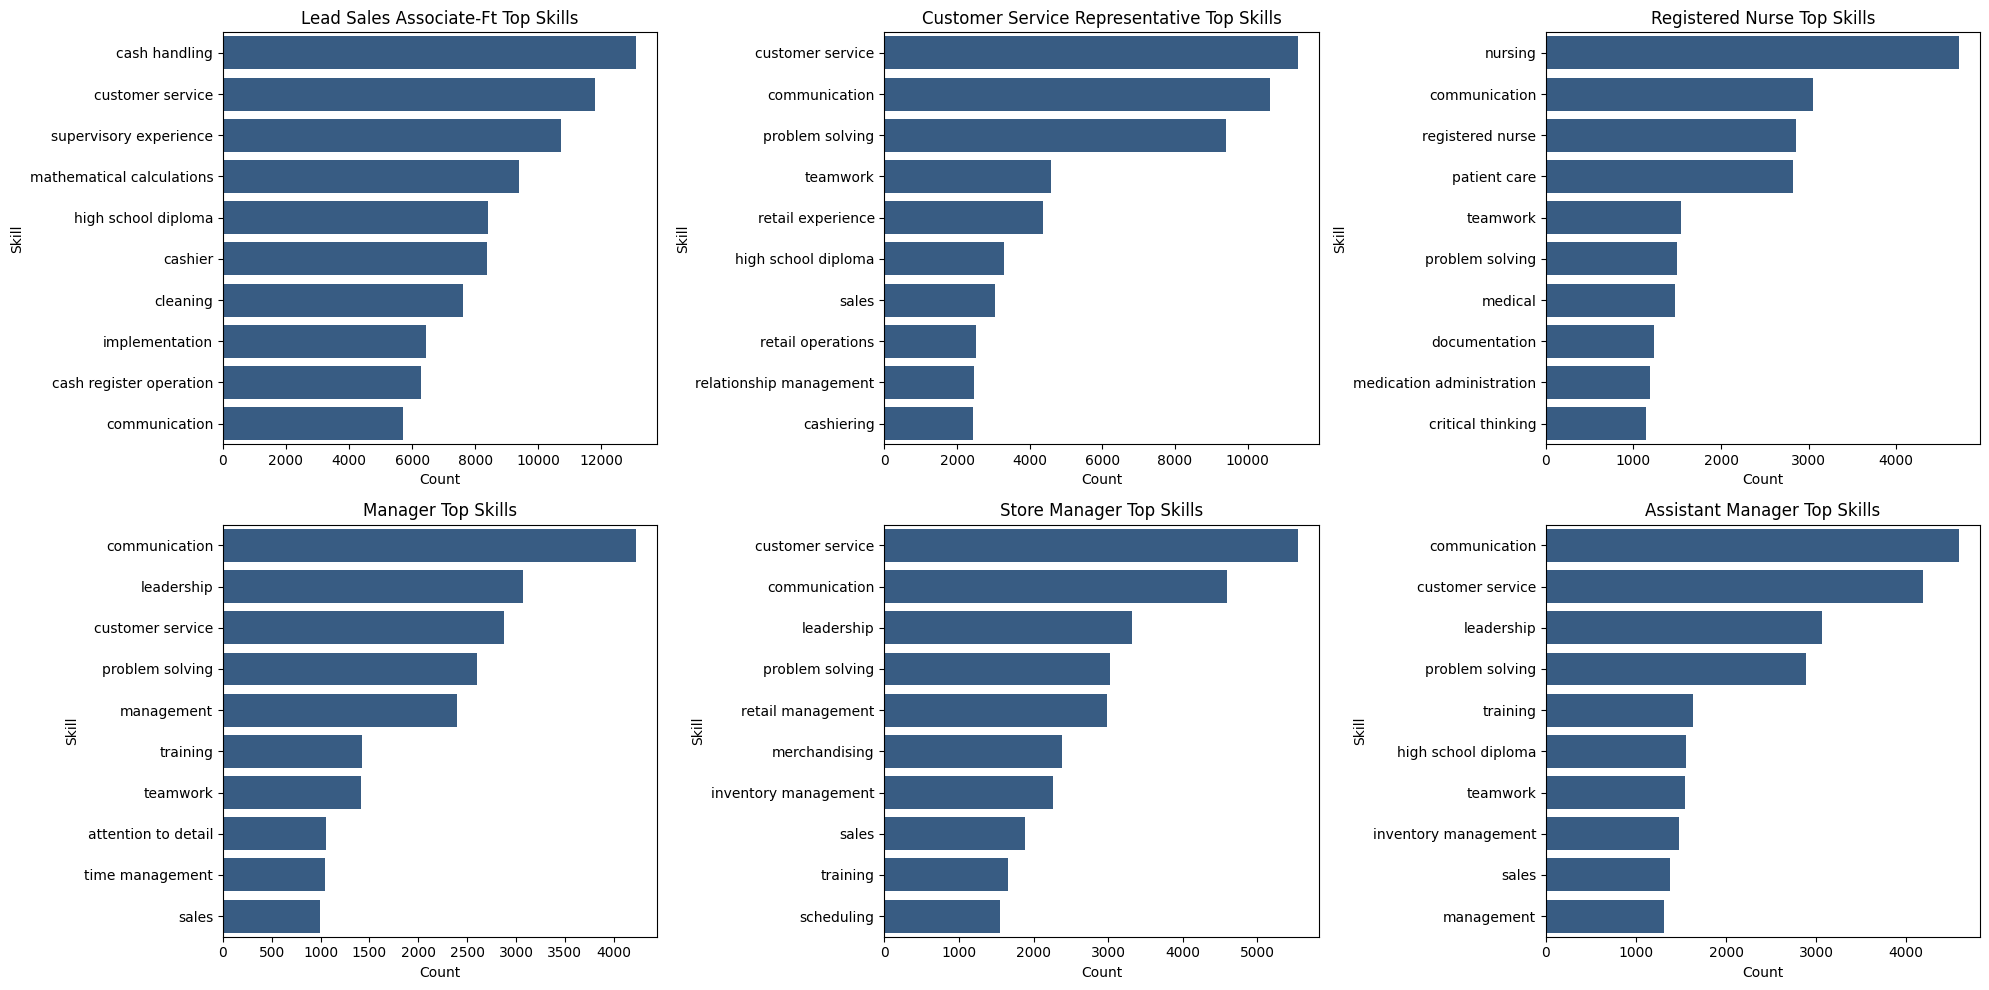

In [38]:
top6_titles = top_titles.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, role in enumerate(top6_titles):
    role_top_skills = top_skills_for_role(role)

    sns.barplot(
        x=role_top_skills.values,
        y=role_top_skills.index,
        color='#2b5c8f',
        ax=axes[i]
    )

    axes[i].set_title(f"{role} Top Skills")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Skill")

plt.tight_layout()
plt.show()

**Key Insight:**

Each job title has a distinct skill fingerprint. For example, "Customer Service Representative" centers on customer service and communication, while "Store Manager" centers on customer service, leadership, and retail management — different roles, different dominant skills. This is significant because job titles alone are unreliable (recall the Long Tail problem from Chart 1), yet the skill patterns behind those titles remain distinguishable. This is the core evidence that skill-based similarity, rather than job-title text, is a viable foundation for matching users to relevant roles.

#### Chart 7: Skill Demand by Job Level

job_level
Mid Senior    19.686203
Associate     19.049852
Name: n_skills, dtype: float64


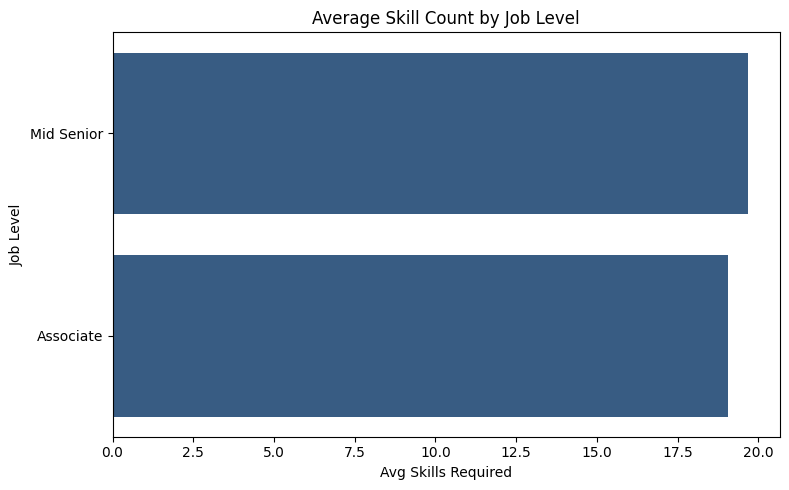

In [39]:
df['n_skills'] = df['job_skills_c'].apply(len)

skills_by_level = df.groupby('job_level')['n_skills'].mean()
skills_by_level = skills_by_level.sort_values(ascending=False)
print(skills_by_level)

plt.figure(figsize=(8, 5))
sns.barplot(x=skills_by_level.values, y=skills_by_level.index, color='#2b5c8f')
plt.title('Average Skill Count by Job Level')
plt.xlabel('Avg Skills Required')
plt.ylabel('Job Level')
plt.tight_layout()
plt.show()

**Key Insight:**

Skill count is fairly stable across seniority levels — Mid-Senior roles require 19.7 skills on average, only marginally more than Associate roles (19.0). This suggests that job level alone is not a strong signal for how many skills a role demands. For Skill Gap analysis, this means the number of "missing skills" shouldn't be assumed to scale sharply with seniority — other factors (like the specific role or skill category) likely matter more than level alone.

# 5. Save data

In [40]:
df.head()

,job_title,company,job_location,first_seen,job_level,job_type,job_skills,job_title_c,job_skills_c,n_skills
0,Account Executive - Dispensing (Norcal Norther...,BD,"San Diego, CA",2024-01-15,Mid Senior,Onsite,"Medical equipment sales, Key competitors, Term...",Account Executive - Dispensing - Becton Dickinson,"[medical sales, key competitors, terminology, ...",25
1,Registered Nurse - Rn Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Mid Senior,Onsite,"Nursing, Bachelor of Science in Nursing, Maste...",Registered Nurse Supervisor,"[nursing, master's degree in nursing, patient ...",15
2,Restaurant Supervisor - The Forklift,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Mid Senior,Onsite,"Restaurant Operations Management, Inventory Ma...",Restaurant Service Manager,"[operations, inventory management, food and be...",38
3,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Mid Senior,Onsite,"Real Estate, Customer Service, Sales, Negotiat...",Associate Real Estate Agent,"[real estate, customer service, sales, negotia...",18
4,Registered Nurse (Rn),Trinity Health MI,"Muskegon, MI",2024-01-14,Mid Senior,Onsite,"Nursing, BSN, Medical License, Virtual RN, Nur...",Registered Nurse,"[nursing, bsn, medical license, virtual, suppo...",9


In [41]:
df.to_csv("linkedin-jobs-and-skills.csv", index=False)